# Binary Logistic Regression — Placement Status

## Objective
Develop a Logistic Regression classification model to predict **`PlacementStatus`** and evaluate it using standard classification metrics.

### Data assumption
The data is already preprocessed:
- `X_train` = 80% preprocessed features
- `X_test` = 20% preprocessed features
- `y_train` = target for training
- `y_test` = target for testing

**No additional imputation, encoding, or scaling is performed here.**

### Required outputs
- `evaluate_classifier()` function
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report
- Coefficient bar chart


## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)


## 2. Load Already-Preprocessed Data

In [3]:
# Change these paths to your actual files
X_TRAIN_PATH = r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\X_train_processed.csv"
X_TEST_PATH  = r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\X_test_processed.csv"
Y_TRAIN_PATH = r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\y_train.csv"
Y_TEST_PATH  = r"C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\y_test.csv"

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH)
y_test = pd.read_csv(Y_TEST_PATH)

if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]
if isinstance(y_test, pd.DataFrame) and y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts().sort_index())


X_train: (40000, 45)
X_test : (10000, 45)
y_train: (40000,)
y_test : (10000,)

Target distribution:
PlacementStatus
0    13715
1    26285
Name: count, dtype: int64


## 3. Verify Preprocessed Data

In [4]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test :", X_test.isna().sum().sum())

print("\nFeature columns:")
print(list(X_train.columns))

print("\nTarget classes:")
print(sorted(pd.Series(y_train).unique()))


Missing values in X_train: 0
Missing values in X_test : 0

Feature columns:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'CollegeTier', 'CGPA_Tier', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']

Target classes:
[np.int64(0), np.int64(1)]


## 4. Train Binary Logistic Regression

In [5]:
model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)


Model trained successfully.
Classes: [0 1]


## 5. Define `evaluate_classifier()`

In [6]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)

    print(f"===== {dataset_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    }


## 6. Evaluate Training and Test Performance

In [7]:
train_results = evaluate_classifier(
    model, X_train, y_train, "Training"
)

test_results = evaluate_classifier(
    model, X_test, y_test, "Test"
)

evaluation_df = pd.DataFrame([
    train_results,
    test_results
])

display(evaluation_df)


===== Training =====
Accuracy : 0.9987
Precision: 0.9981
Recall   : 1.0000
F1-score : 0.9990
ROC-AUC  : 0.9981

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13715
           1       1.00      1.00      1.00     26285

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

Confusion Matrix:
[[13664    51]
 [    1 26284]]
===== Test =====
Accuracy : 0.9981
Precision: 0.9973
Recall   : 0.9998
F1-score : 0.9986
ROC-AUC  : 0.9973

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3429
           1       1.00      1.00      1.00      6571

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

Confusion Matrix:
[[3411   18]


,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC
0,Training,0.9987,0.998063,0.999962,0.999012,0.998113
1,Test,0.9981,0.997268,0.999848,0.998556,0.997325


## 7. Test Confusion Matrix

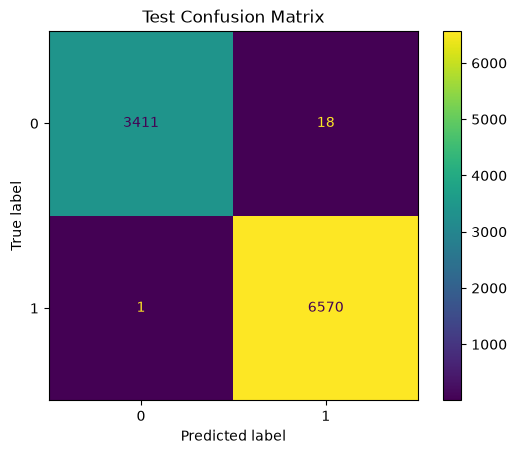

In [8]:
y_test_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    values_format="d"
)

plt.title("Test Confusion Matrix")
plt.show()


## 8. Coefficients

In [9]:
# Binary: one coefficient per feature.
# Multinomial: one coefficient row per class.

if model.coef_.shape[0] == 1:
    coefficient_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": model.coef_[0]
    })
    display(coefficient_df)

else:
    coefficient_df = pd.DataFrame(
        model.coef_,
        index=[f"Class={c}" for c in model.classes_],
        columns=X_train.columns
    )
    display(coefficient_df)


,Feature,Coefficient
0,StudentID,-0.019554
1,SGPA_Sem1,0.285838
2,SGPA_Sem2,0.114367
3,SGPA_Sem3,0.255517
4,SGPA_Sem4,0.220199
5,SGPA_Sem5,0.504266
6,SGPA_Sem6,0.394002
7,SGPA_Sem7,0.377294
8,SGPA_Sem8,0.398298
9,CGPA,-0.924342


## 9. Coefficient Bar Chart

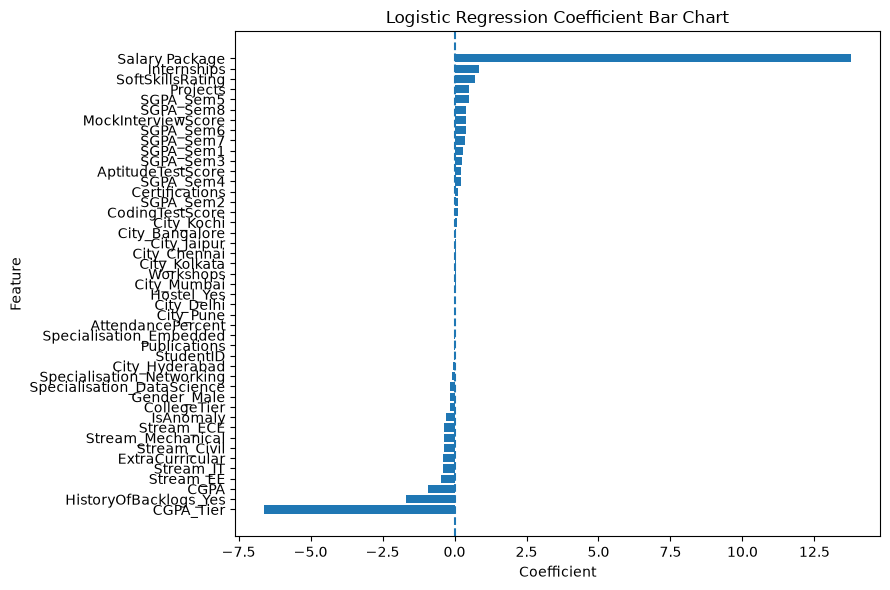

In [10]:
if model.coef_.shape[0] == 1:

    plot_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": model.coef_[0]
    }).sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["Feature"], plot_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Logistic Regression Coefficient Bar Chart")
    plt.tight_layout()
    plt.show()

else:
    coefficient_plot_df = coefficient_df.T

    ax = coefficient_plot_df.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title("Multinomial Logistic Regression Coefficient Bar Chart")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Interpretation and Conclusion

### Target
This notebook predicts **`PlacementStatus`**.

### Metrics
- Accuracy: overall percentage of correct predictions.
- Precision: correctness of positive predictions.
- Recall: ability to identify actual positive cases.
- F1-score: balance between precision and recall.
- ROC-AUC: used for the binary model to measure discrimination across thresholds.

### Coefficients
A positive coefficient increases the model's tendency toward the corresponding class; a negative coefficient decreases it, subject to the preprocessing and class formulation.

### Final evaluation
The **test-set metrics** are the final performance results because `X_test` and `y_test` are kept separate from model fitting.
